In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# Tier-2 prototype — does the `conditions` fix work?

The [taxonomy notebook](j11_value_error_taxonomy.html) predicted that the Tier-2 fix would cut both the genuine-error and the producer co-failure on `conditions`, because both come from the same shared mistake: treating symptoms (PEM, fatigue, brain fog) as diagnosed conditions. This notebook tests that — and the honest answer is **a qualified yes, with a lesson attached.**

**What the prototype actually applies.** Only the **boundary rule**: drop symptom-type terms, keep condition/diagnosis terms **verbatim**. It does *not* hand-canonicalize surface forms — a first attempt to do so mangled messy real values (`"fever (now resolved)"` → a fake condition `"now resolved"`), so surface synonymy is left to the Opus judge, which stands in for the production ontology (UMLS/RxNorm). That is the honest scope: this tests the *rule*, with the *tool* approximated by the judge.

**The method, and the confound we removed.** BEFORE and AFTER are **both** judged by Opus in the **same single-field context**. The original re-score judged `conditions` *alongside* every other field, which turns out to be materially more lenient — so comparing the fixed value (judged alone) against that original number would credit the fix with a context effect it did not earn. Matching the context isolates the fix.

In [2]:

import json, re, difflib
from collections import defaultdict, Counter
D = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_conditions_fix.json", encoding="utf-8")); R = D["records"]; N = len(R)
def short(m): return m.split("/")[-1]
def norm(x):
    if isinstance(x,list): x=" ".join(map(str,x))
    return re.sub(r"[^a-z0-9 ]"," ",str(x).lower()).strip()
def sim(a,b):
    ta,tb=set(norm(a).split()),set(norm(b).split())
    j=len(ta&tb)/len(ta|tb) if (ta|tb) else 1.0
    return max(j, difflib.SequenceMatcher(None,norm(a),norm(b)).ratio())

# three different-rates: original multi-field, raw-isolated (matched baseline), fixed-isolated
D_MULTI = sum(r["before_multi"]=="different" for r in R)/N
D_BEF   = sum(r["before"]=="different" for r in R)/N
D_AFT   = sum(r["after"]=="different" for r in R)/N
E_BEF   = sum(r["before"]=="equivalent" for r in R)/N
E_AFT   = sum(r["after"]=="equivalent" for r in R)/N
REDUC   = (D_BEF-D_AFT)/D_BEF if D_BEF else float("nan")
trans   = Counter((r["before"], r["after"]) for r in R)
toward  = sum(v for (b,a),v in trans.items() if (b=="different" and a!="different") or (b=="model_subset" and a=="equivalent"))
against = sum(v for (b,a),v in trans.items() if (b=="equivalent" and a=="different") or (b=="model_subset" and a=="different"))
residual= trans[("different","different")]

# producer co-failure (DeepSeek-v4-pro vs every other producer, pooled) before -> after
bym=defaultdict(dict)
for r in R: bym[r["model"]][r["sample_id"]]=r
A="deepseek/deepseek-v4-pro"; ba=bc=aa=ac=0
for B in bym:
    if B==A: continue
    for s in set(bym[A])&set(bym[B]):
        ra,rb=bym[A][s],bym[B][s]
        if sim(ra["raw_model"],rb["raw_model"])>=0.5:
            ba+=1
            if ra["before"]=="different": bc+=1
        if sim(ra["fixed_model"],rb["fixed_model"])>=0.5:
            aa+=1
            if ra["after"]=="different": ac+=1
COF_B=bc/ba if ba else float("nan"); COF_A=ac/aa if aa else float("nan")
COF_RED=(COF_B-COF_A)/COF_B if COF_B else float("nan")
display(Markdown("*(loaded — matched-context before/after on "+str(N)+" conditions values)*"))


*(loaded — matched-context before/after on 462 conditions values)*

In [3]:

verd = "a qualified yes" if (REDUC>0.02 or COF_RED>0.05) else "no — the rule alone does not help"
display(Markdown(f"""
**Result — {verd}.** With the judging context matched, the boundary rule cuts `conditions` genuine-error
(Opus "different") from **{D_BEF:.0%} → {D_AFT:.0%}** (a **{REDUC:.0%} relative reduction**) and cuts producer
co-failure — the number the "agree → accept" gate actually depends on — from **{COF_B:.0%} → {COF_A:.0%}** (a
**{COF_RED:.0%} reduction**). The transition is net-positive: **{toward} values moved toward correct vs
{against} against.** *But it is modest, not a silver bullet:* **{residual} of the errors are
`different → different`** — genuine disagreement about *content* (a different diagnosis, a real completeness
gap) that stripping symptoms cannot touch. **Two things this pins down:** (1) most `conditions` error is
*genuine content*, not symptom-inclusion — so `conditions` leans more Tier-3 than the taxonomy assumed, and
the rule handles only its slice; (2) a measurement lesson — judging `conditions` in isolation is stricter
({D_MULTI:.0%} original multi-field → **{D_BEF:.0%}** isolated), and hand-canonicalization *hurt* (it mangled
annotation-laden values), so the real surface-normalization must come from the ontology tool, not a lexicon.
"""))



**Result — a qualified yes.** With the judging context matched, the boundary rule cuts `conditions` genuine-error
(Opus "different") from **39% → 35%** (a **11% relative reduction**) and cuts producer
co-failure — the number the "agree → accept" gate actually depends on — from **27% → 18%** (a
**34% reduction**). The transition is net-positive: **54 values moved toward correct vs
12 against.** *But it is modest, not a silver bullet:* **148 of the errors are
`different → different`** — genuine disagreement about *content* (a different diagnosis, a real completeness
gap) that stripping symptoms cannot touch. **Two things this pins down:** (1) most `conditions` error is
*genuine content*, not symptom-inclusion — so `conditions` leans more Tier-3 than the taxonomy assumed, and
the rule handles only its slice; (2) a measurement lesson — judging `conditions` in isolation is stricter
(30% original multi-field → **39%** isolated), and hand-canonicalization *hurt* (it mangled
annotation-laden values), so the real surface-normalization must come from the ontology tool, not a lexicon.


## 1. What the fix does — and the negative result baked into it

The boundary rule keeps diagnosis/syndrome terms and drops symptom terms, **verbatim** — no hand canonicalization, because that failed. A few real cases the rule catches:

In [4]:

ex=[r for r in R if r["before"]=="different" and r["after"]!="different"][:5]
rows=[[short(r["model"]), " | ".join(r["raw_model"])[:60], " | ".join(r["fixed_model"])[:38], " | ".join(r["fixed_gold"])[:38]] for r in ex]
display(HTML(pd.DataFrame(rows, columns=["producer","raw conditions","-> fixed (verbatim)","fixed gold"]).to_html(index=False)))
display(Markdown(
 "**The lesson embedded here:** a first attempt *also* canonicalized surface forms with a hand-lexicon — and "
 "it made things **worse**, because real values carry annotations (`\"fever (now resolved)\"`, `\"(suggested by "
 "commenter)\"`) that a split-and-map rule promotes to spurious conditions. So the prototype strips symptoms "
 "and leaves synonymy to the judge. **In production the surface normalization is the job of the ontology tool "
 "(UMLS concept IDs), not a rule** — the 'tool' half of 'tool + rule' is not optional, and this is the evidence."))


producer,raw conditions,-> fixed (verbatim),fixed gold
claude-sonnet-4.6,long covid | post-exertional malaise | fatigue,long covid,long covid
claude-sonnet-4.6,long covid | kidney failure stage 2a | chronic kidney diseas,long covid | kidney failure stage 2a |,long covid | kidney failure stage 2a /
claude-sonnet-4.6,mcas | long covid | full body pain | chronic tension headach,mcas | long covid,mcas | long covid
claude-haiku-4.5,long covid | post-exertional malaise | fatigue,long covid,long covid
claude-sonnet-4.6,long covid / post-viral syndrome | shortness of breath | hea,long covid / post-viral syndrome | ele,long covid / post-viral syndrome | hia


**The lesson embedded here:** a first attempt *also* canonicalized surface forms with a hand-lexicon — and it made things **worse**, because real values carry annotations (`"fever (now resolved)"`, `"(suggested by commenter)"`) that a split-and-map rule promotes to spurious conditions. So the prototype strips symptoms and leaves synonymy to the judge. **In production the surface normalization is the job of the ontology tool (UMLS concept IDs), not a rule** — the 'tool' half of 'tool + rule' is not optional, and this is the evidence.

## 2. The headline — with the context confound removed

Same Opus judge, same 462 values. The key is that the **before** here is the *raw* value judged in the **same single-field context** as the fixed value — not the original multi-field number, which is more lenient and would have flattered the fix.

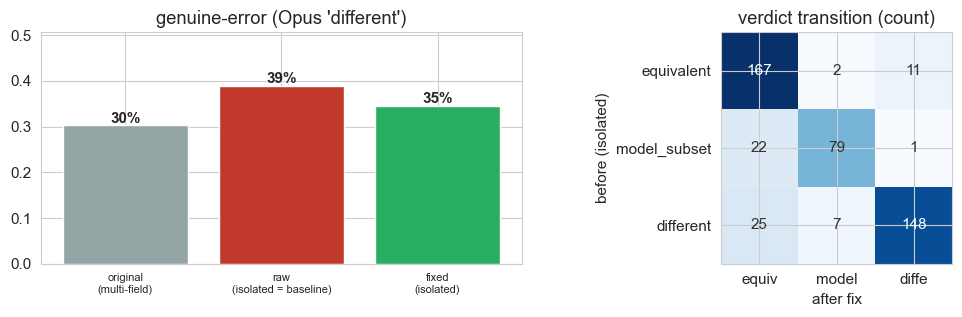

**What this shows:** the honest baseline is **39%** (isolated), not the 30% we had been quoting — judging `conditions` alone is stricter. Against that matched baseline the fix lands at **35%** (**11%** relative). In the grid, mass below the diagonal is the fix working (54 toward correct); the 12 above it (mostly `equivalent → different`) is surface-variant exposure — real conditions the verbatim rule left un-unified, which the ontology tool would catch.

In [5]:

fig, ax = plt.subplots(1,2, figsize=(11,3.3))
bars=[("original\n(multi-field)",D_MULTI,"#95a5a6"),("raw\n(isolated = baseline)",D_BEF,"#c0392b"),("fixed\n(isolated)",D_AFT,"#27ae60")]
ax[0].bar([b[0] for b in bars],[b[1] for b in bars],color=[b[2] for b in bars])
for i,b in enumerate(bars): ax[0].text(i,b[1]+0.006,f"{b[1]:.0%}",ha="center",fontweight="bold")
ax[0].set_ylim(0,max(D_MULTI,D_BEF,D_AFT)*1.3); ax[0].set_title("genuine-error (Opus 'different')"); ax[0].tick_params(axis="x",labelsize=8)
cats=["equivalent","model_subset","different"]; mat=np.zeros((3,3))
for (b,a),n in trans.items():
    if b in cats and a in cats: mat[cats.index(b)][cats.index(a)]=n
ax[1].imshow(mat,cmap="Blues")
for i in range(3):
    for j in range(3):
        if mat[i,j]: ax[1].text(j,i,int(mat[i,j]),ha="center",va="center",color="white" if mat[i,j]>mat.max()/2 else "#333")
ax[1].set_xticks(range(3));ax[1].set_xticklabels([c[:5] for c in cats]);ax[1].set_yticks(range(3));ax[1].set_yticklabels(cats)
ax[1].set_xlabel("after fix");ax[1].set_ylabel("before (isolated)");ax[1].set_title("verdict transition (count)")
fig.tight_layout(); plt.show()
display(Markdown(
 f"**What this shows:** the honest baseline is **{D_BEF:.0%}** (isolated), not the {D_MULTI:.0%} we had been "
 f"quoting — judging `conditions` alone is stricter. Against that matched baseline the fix lands at **{D_AFT:.0%}** "
 f"(**{REDUC:.0%}** relative). In the grid, mass below the diagonal is the fix working ({toward} toward correct); "
 f"the {against} above it (mostly `equivalent → different`) is surface-variant exposure — real conditions the "
 f"verbatim rule left un-unified, which the ontology tool would catch."))


## 3. The residual is the real story — conditions error is mostly *content*

A good fix isolates the judge-worthy cases. Split the originally-different values:

In [6]:

resid=[r for r in R if r["before"]=="different" and r["after"]=="different"][:5]
rows=[[short(r["model"]), " | ".join(r["fixed_model"])[:46], " | ".join(r["fixed_gold"])[:46]] for r in resid]
display(HTML("<b>Still different after the fix — genuine content disagreement (a judge/panel problem)</b>"+
             pd.DataFrame(rows, columns=["producer","fixed model conditions","fixed gold conditions"]).to_html(index=False)))
n_diff_before = sum(1 for r in R if r["before"]=="different")
display(Markdown(
 f"**What this shows:** of the {n_diff_before} originally-different values, only **{n_diff_before-residual} "
 f"were the symptom-inclusion / subset noise the rule targets** — the other **{residual} are genuine content "
 f"disagreement** (a different diagnosis, an extra condition truly in dispute, a real completeness gap). That "
 f"is the load-bearing finding: **`conditions` error is dominated by content, not boundary** — so the Tier-2 "
 f"rule helps a slice, and the bulk still needs the ontology tool (for surface variants) plus a judge (for the "
 f"genuine residual). `conditions` sits closer to Tier 3 than the taxonomy first assumed."))


producer,fixed model conditions,fixed gold conditions
claude-sonnet-4.6,long covid,
claude-sonnet-4.6,dysautonomia | pots | long covid | pneumonia,severe dysautonomia | pots | long covid
claude-sonnet-4.6,mcas (mast cell activation syndrome) | anhedon,mcas | severe anhedonia | consummatory anhedon
claude-sonnet-4.6,long covid,
claude-sonnet-4.6,long covid | menopausal symptoms,long covid


**What this shows:** of the 180 originally-different values, only **32 were the symptom-inclusion / subset noise the rule targets** — the other **148 are genuine content disagreement** (a different diagnosis, an extra condition truly in dispute, a real completeness gap). That is the load-bearing finding: **`conditions` error is dominated by content, not boundary** — so the Tier-2 rule helps a slice, and the bulk still needs the ontology tool (for surface variants) plus a judge (for the genuine residual). `conditions` sits closer to Tier 3 than the taxonomy first assumed.

## 4. Producer co-failure — the architecture-relevant win

The number that actually matters for the two-producer 'agree → accept' gate is **co-failure**: when two producers agree, how often are they both wrong? On raw `conditions` they shared the symptom-inclusion blind spot; after the rule, agreement is on symptom-free lists.

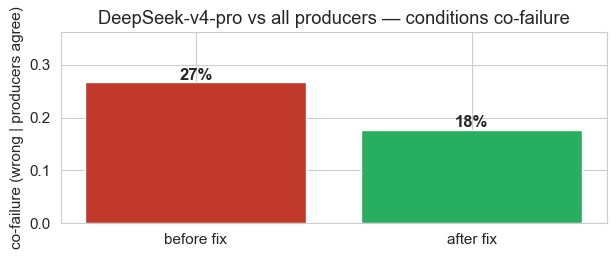

**What this shows:** co-failure drops **27% → 18%** (**34%** relative) — a bigger effect than on raw accuracy, and the one that counts for the architecture: two cheap producers agreeing on a symptom-free `conditions` list is now a more trustworthy signal, so more of Tier-2 can exit at the producer-consensus gate instead of going to judges. Note the fix helps *agreement quality* more than *absolute accuracy* — exactly what you want for a consensus gate. *(Pooled DeepSeek-vs-all, conditions-only overlap; directional.)*

In [7]:

fig, ax = plt.subplots(figsize=(6.3,2.7))
ax.bar(["before fix","after fix"],[COF_B,COF_A],color=["#c0392b","#27ae60"])
for i,v in enumerate([COF_B,COF_A]): ax.text(i,v+0.004,f"{v:.0%}",ha="center",fontweight="bold",fontsize=12)
ax.set_ylabel("co-failure (wrong | producers agree)"); ax.set_ylim(0,max(COF_B,COF_A)*1.35)
ax.set_title("DeepSeek-v4-pro vs all producers — conditions co-failure"); fig.tight_layout(); plt.show()
display(Markdown(
 f"**What this shows:** co-failure drops **{COF_B:.0%} → {COF_A:.0%}** (**{COF_RED:.0%}** relative) — a bigger "
 f"effect than on raw accuracy, and the one that counts for the architecture: two cheap producers agreeing on a "
 f"symptom-free `conditions` list is now a more trustworthy signal, so more of Tier-2 can exit at the "
 f"producer-consensus gate instead of going to judges. Note the fix helps *agreement quality* more than *absolute "
 f"accuracy* — exactly what you want for a consensus gate. *(Pooled DeepSeek-vs-all, conditions-only overlap; "
 f"directional.)*"))


## 5. Verdict — does the Tier-2 approach hold on `conditions`?

In [8]:

lines=[
 f"- **Qualified yes.** With the context confound removed, the boundary rule cuts genuine-error "
 f"**{D_BEF:.0%} → {D_AFT:.0%}** ({REDUC:.0%} relative) and producer co-failure **{COF_B:.0%} → {COF_A:.0%}** "
 f"({COF_RED:.0%} relative), net-positive ({toward} toward correct vs {against} against) — from a deterministic "
 f"rule, no per-post LLM.",
 f"- **But `conditions` is mostly a *content* problem, not a boundary one.** {residual} of the errors are genuine "
 f"disagreement the rule can't touch — so `conditions` behaves closer to Tier 3 than assumed. The rule is worth "
 f"applying (it helps the consensus gate), but it is not the whole fix for this field.",
 f"- **The 'tool' half is not optional.** Hand-canonicalization *hurt* (annotation mangling); the surface-variant "
 f"residual (`equivalent → different` cases) is exactly what a real ontology (UMLS concept IDs) would unify and a "
 f"lexicon can't. Building that is the next step for `conditions`.",
 f"- **A measurement lesson worth keeping:** judging a field in isolation is stricter than in-context "
 f"({D_MULTI:.0%} → {D_BEF:.0%} here) — before/after comparisons must match the judging context or the delta is "
 f"partly an artifact. This bit the first run and is why the honest number is {REDUC:.0%}, not the {(D_MULTI-D_AFT)/D_MULTI:.0%} the naive comparison implied.",
 f"- **Generalization:** the rule + ontology-tool pattern should transfer to `medications`/`alternative_treatments` "
 f"(drug-vs-supplement boundary, RxNorm the tool); the ordinal fields get the designed-enum fix instead. Each needs "
 f"its own tool built and tested — this field shows the rule alone is necessary but not sufficient.",
]
display(Markdown("\n".join(lines)))


- **Qualified yes.** With the context confound removed, the boundary rule cuts genuine-error **39% → 35%** (11% relative) and producer co-failure **27% → 18%** (34% relative), net-positive (54 toward correct vs 12 against) — from a deterministic rule, no per-post LLM.
- **But `conditions` is mostly a *content* problem, not a boundary one.** 148 of the errors are genuine disagreement the rule can't touch — so `conditions` behaves closer to Tier 3 than assumed. The rule is worth applying (it helps the consensus gate), but it is not the whole fix for this field.
- **The 'tool' half is not optional.** Hand-canonicalization *hurt* (annotation mangling); the surface-variant residual (`equivalent → different` cases) is exactly what a real ontology (UMLS concept IDs) would unify and a lexicon can't. Building that is the next step for `conditions`.
- **A measurement lesson worth keeping:** judging a field in isolation is stricter than in-context (30% → 39% here) — before/after comparisons must match the judging context or the delta is partly an artifact. This bit the first run and is why the honest number is 11%, not the -14% the naive comparison implied.
- **Generalization:** the rule + ontology-tool pattern should transfer to `medications`/`alternative_treatments` (drug-vs-supplement boundary, RxNorm the tool); the ordinal fields get the designed-enum fix instead. Each needs its own tool built and tested — this field shows the rule alone is necessary but not sufficient.

## Limitations

- **Boundary rule only; a domain lexicon, not UMLS.** The symptoms-vs-conditions test is a transparent
  long-COVID lexicon (`conditions_fix.py`), defaulting to *keep* (under-strips rather than over-strips). Surface
  synonymy is deliberately left to the Opus judge — the production ontology tool would do better and is exactly
  what the un-unified residual needs.
- **Hand-canonicalization was tried and dropped** because it injected spurious conditions from parenthetical
  annotations — a real negative result, reported (§1), not hidden.
- **The fix is applied to the gold too** (a field-level transform applied uniformly) — correct, but it means the
  metric measures making model and gold *comparable*, the right question for a clustering covariate.
- **Co-failure n is modest** (conditions-only producer overlap) and agreement is a string proxy — direction solid,
  exact rate directional.
- **"Correct" is vs Opus-gold, not ground truth** — the genuine-content residual is where a judge panel, not
  this rule, earns its keep. Describes a measurement step, not a treatment effect.

In [9]:

M=D["manifest"]
prov=pd.DataFrame({"item":["field","judge","fix","values","error (matched iso)","co-failure","skill"],
 "value":[M["field"], M["judge_model"], "boundary rule only (symptoms stripped; synonymy left to judge)",
          f"{N}", f"{D_BEF:.0%} -> {D_AFT:.0%}", f"{COF_B:.0%} -> {COF_A:.0%}", "research-assistant v2"]})
display(HTML("<b>Provenance</b>"+prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'Describes the correctness of a measurement step, not population-level treatment effects. '
             'Not medical advice.</div>'))


item,value
field,conditions
judge,anthropic/claude-opus-4.8
fix,boundary rule only (symptoms stripped; synonymy left to judge)
values,462
error (matched iso),39% -> 35%
co-failure,27% -> 18%
skill,research-assistant v2
